# Preparação da base e definição dos braços (Etapa 2)

- Feature engineering (encoding categórico, normalização)
- Definição e documentação dos braços simulados do bandit + regra de probabilidade-base/ruído
- Split treino vs. simulação online
- Salvar dataset processado em `data/processed/`

A lógica reaproveitável está em `src/features.py` e `src/arms.py` (para poder
ser importada novamente na Etapa 3 e no serviço da Etapa 5).

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features import load_raw, build_features, NUMERIC_COLS
from src.arms import simulate_arm_probabilities, arms_metadata, ARM_DEFINITIONS

pd.set_option("display.max_columns", 50)

## 1. Carregar base bruta

Mesma base da EDA (`data/raw/bank-additional-full.csv`).

In [2]:
RAW_PATH = "../data/raw/bank-additional-full.csv"

df_raw = load_raw(RAW_PATH)
print("Shape bruto:", df_raw.shape)
df_raw.head(3)

Shape bruto: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Feature engineering

Decisões (conforme EDA):
- `duration` é removida (vazamento temporal).
- `pdays` é transformada na flag binária `foi_contatado_antes` (999 = nunca contatado, ~96% da base).
- Colunas categóricas (`job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`) recebem one-hot encoding, mantendo `unknown` como categoria própria.
- Colunas numéricas (`age`, `campaign`, `previous` e as macroeconômicas) são normalizadas via `StandardScaler` (z-score).
- O target `y` é convertido para binário (1 = `yes`).

In [3]:
df_features, scaler = build_features(df_raw)

print("Shape após feature engineering:", df_features.shape)
print("\nColunas removidas/transformadas -> 'pdays' presente?", "pdays" in df_features.columns)
print("Flag 'foi_contatado_antes' presente?", "foi_contatado_antes" in df_features.columns)
print("\nMédia (~0) e desvio (~1) das numéricas após normalização:")
display_df = pd.DataFrame({
    "media": df_features[NUMERIC_COLS].mean().round(3),
    "desvio": df_features[NUMERIC_COLS].std().round(3),
})
display_df

Shape após feature engineering: (41188, 63)

Colunas removidas/transformadas -> 'pdays' presente? False
Flag 'foi_contatado_antes' presente? True

Média (~0) e desvio (~1) das numéricas após normalização:


,media,desvio
age,-0.0,1.0
campaign,-0.0,1.0
previous,0.0,1.0
emp.var.rate,-0.0,1.0
cons.price.idx,-0.0,1.0
cons.conf.idx,-0.0,1.0
euribor3m,-0.0,1.0
nr.employed,0.0,1.0


In [4]:
print("Nº de colunas após one-hot encoding:", df_features.shape[1])
print("Nº de valores nulos no dataset final:", df_features.isnull().sum().sum())
df_features.head(3)

Nº de colunas após one-hot encoding: 63
Nº de valores nulos no dataset final: 0


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,foi_contatado_antes,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,...,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,contact_cellular,contact_telephone,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,1.533034,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,0,0,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
1,1.628993,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,...,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
2,-0.290186,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,...,False,True,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False


## 3. Definição e documentação dos braços simulados

O dataset `bank-marketing` tem um único produto real (depósito a prazo), então
simulamos **4 braços** = variações de mensagem/canal para essa mesma oferta.

Cada braço tem uma **probabilidade-base de conversão** derivada da taxa real
do dataset (`p_global`), ajustada por um multiplicador de segmento ancorado em
sinais que a EDA já mostrou serem reais (poutcome, job, mês, contato prévio),
mais um ruído gaussiano controlado. A regra completa está documentada em
`src/arms.py` (`ARM_DEFINITIONS`, `_segment_multiplier`, `simulate_arm_probabilities`).

**Limitação assumida e documentada:** os 4 braços não existiram de fato na
campanha original, é uma simulação para viabilizar o requisito do bandit,
não um dado real apresentado como tal.

In [5]:
for m in arms_metadata():
    print(f"Arm {m['arm']} — {m['nome']} (multiplicador-base={m['multiplicador_base']})")
    print(f"   {m['descricao']}\n")

Arm 0 — Oferta padrão (multiplicador-base=1.0)
   Mensagem genérica via canal telefônico, sem personalização. Serve como braço de referência (comportamento histórico médio).

Arm 1 — Oferta com apelo a benefício/taxa (multiplicador-base=1.1)
   Mensagem com destaque para taxa/benefício financeiro do produto. Boost simulado para perfis com job em admin./management/technician ou educação superior, segmentos com maior engajamento observado na EDA.

Arm 2 — Oferta reforçada para quem já converteu (multiplicador-base=1.0)
   Mensagem personalizada para clientes com poutcome == 'success' (já converteram em campanha anterior) ou previous > 0. A EDA mostrou que poutcome='success' tem taxa de conversão muito acima da média — maior ganho simulado, mas segmento pequeno.

Arm 3 — Oferta introdutória (primeiro contato) (multiplicador-base=0.85)
   Mensagem mais leve para quem nunca foi contatado antes (pdays == 999, ~96% da base), estudantes/aposentados e meses de maior conversão histórica (mar, de

In [6]:
arm_probs = simulate_arm_probabilities(df_raw)
print("Shape das probabilidades por braço:", arm_probs.shape)
arm_probs.describe().round(4)

Shape das probabilidades por braço: (41188, 4)


,p_arm_0,p_arm_1,p_arm_2,p_arm_3
count,41188.0000,41188.0000,41188.0000,41188.0000
mean,0.1127,0.1346,0.1150,0.1158
std,0.0201,0.0220,0.0215,0.0209
min,0.0249,0.0458,0.0362,0.0358
25%,0.0993,0.1199,0.1004,0.1018
50%,0.1127,0.1347,0.1143,0.1158
75%,0.1262,0.1495,0.1289,0.1298
max,0.1992,0.2427,0.2201,0.2117


### Checagem de sanidade: o multiplicador de segmento realmente diferencia os braços?

Se a regra estiver correta, clientes com `poutcome == 'success'` devem ter
`p_arm_2` bem mais alto que a média (arm 2 foi desenhado para esse segmento),
e clientes nunca contatados antes devem ter `p_arm_3` mais alto que quem já
foi contatado (arm 3 foi desenhado para primeiro contato).

In [7]:
mask_success = df_raw["poutcome"] == "success"
mask_never_contacted = df_raw["pdays"] == 999

resumo = pd.DataFrame({
    "p_arm_2 | poutcome=success": [arm_probs.loc[mask_success, "p_arm_2"].mean()],
    "p_arm_2 | poutcome!=success": [arm_probs.loc[~mask_success, "p_arm_2"].mean()],
    "p_arm_3 | nunca contatado": [arm_probs.loc[mask_never_contacted, "p_arm_3"].mean()],
    "p_arm_3 | contatado antes": [arm_probs.loc[~mask_never_contacted, "p_arm_3"].mean()],
}).T.rename(columns={0: "probabilidade media"})
resumo.round(4)

,probabilidade media
p_arm_2 | poutcome=success,0.1519
p_arm_2 | poutcome!=success,0.1137
p_arm_3 | nunca contatado,0.1164
p_arm_3 | contatado antes,0.1022


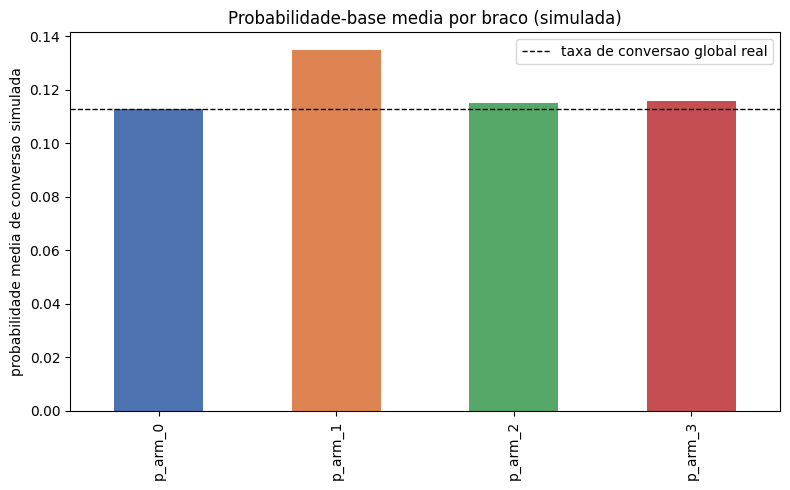

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
arm_probs.mean().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.axhline((df_raw["y"] == "yes").mean(), color="black", linestyle="--", linewidth=1, label="taxa de conversao global real")
ax.set_ylabel("probabilidade media de conversao simulada")
ax.set_title("Probabilidade-base media por braco (simulada)")
ax.legend()
plt.tight_layout()
plt.show()

**Leitura:** a checagem confirma o comportamento esperado: `p_arm_2` é
sensivelmente maior no segmento com `poutcome = success`, e `p_arm_3` é maior
para clientes nunca contatados antes. Isso mostra que **não existe um braço
universalmente melhor** para todo cliente (a base do requisito de um bandit
*contextual*): o braço 1 tem a maior média geral, mas o braço 2 é o melhor
especificamente para quem já converteu antes.

## 4. Split treino vs. simulação online (Task 2.1.3)

O dataset não tem coluna de ano (só `month`/`day_of_week`), então uma ordenação
temporal estrita não é confiável. Campanhas de anos diferentes podem
compartilhar o mesmo mês. Por isso, o split adotado é **aleatório estratificado
por `y`**, preservando a taxa de conversão global em ambos os conjuntos
(decisão documentada, não um dado real de data/hora inventado).

- **treino (70%)**: usado na Etapa 3 para calcular o baseline determinístico e
  priors iniciais.
- **simulação online (30%)**: usado na Etapa 3 para simular a chegada
  sequencial de clientes e rodar o bandit (Thompson Sampling / Epsilon-Greedy)
  round a round.

In [9]:
from sklearn.model_selection import train_test_split

SPLIT_SEED = 42
ONLINE_SIM_SIZE = 0.30

idx_train, idx_online = train_test_split(
    df_features.index,
    test_size=ONLINE_SIM_SIZE,
    stratify=df_features["y"],
    random_state=SPLIT_SEED,
)

df_train = df_features.loc[idx_train].reset_index(drop=True)
df_online = df_features.loc[idx_online].reset_index(drop=True)

arm_probs_train = arm_probs.loc[idx_train].reset_index(drop=True)
arm_probs_online = arm_probs.loc[idx_online].reset_index(drop=True)

print("Treino:", df_train.shape, "| taxa de conversao:", df_train["y"].mean().round(4))
print("Simulacao online:", df_online.shape, "| taxa de conversao:", df_online["y"].mean().round(4))

Treino: (28831, 63) | taxa de conversao: 0.1127
Simulacao online: (12357, 63) | taxa de conversao: 0.1126


## Salvar dataset processado

Persistimos em `data/processed/`:
- `train.csv` features + target (70%), para baseline/priors da Etapa 3
- `online_sim.csv` features + target (30%), para a simulação online da Etapa 3
- `arm_probabilities_train.csv` / `arm_probabilities_online.csv` probabilidade
  simulada por braço (`p_arm_0..p_arm_3`), alinhada linha a linha com os dataframes acima
- `arms_definition.json` metadata dos braços (nome, descrição, multiplicador-base), para consulta no README/Etapa 3

In [10]:
import json
import os

PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

df_train.to_csv(f"{PROCESSED_DIR}/train.csv", index=False)
df_online.to_csv(f"{PROCESSED_DIR}/online_sim.csv", index=False)
arm_probs_train.to_csv(f"{PROCESSED_DIR}/arm_probabilities_train.csv", index=False)
arm_probs_online.to_csv(f"{PROCESSED_DIR}/arm_probabilities_online.csv", index=False)

with open(f"{PROCESSED_DIR}/arms_definition.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "seed": 42,
            "noise_std": 0.02,
            "p_min": 0.01,
            "p_max": 0.95,
            "arms": arms_metadata(),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

print("Arquivos salvos em", os.path.abspath(PROCESSED_DIR))
for fname in sorted(os.listdir(PROCESSED_DIR)):
    print(" -", fname)

Arquivos salvos em /tmp/repo/data/processed
 - arm_probabilities_online.csv
 - arm_probabilities_train.csv
 - arms_definition.json
 - online_sim.csv
 - train.csv


## Resumo da Etapa 2

- Feature engineering aplicada: remoção de `duration`, flag `foi_contatado_antes`
  (a partir de `pdays`), one-hot encoding das categóricas (mantendo `unknown`) e
  normalização (`StandardScaler`) das numéricas. Dataset final com
  63 colunas de feature (incluindo target).
- 4 braços simulados definidos e documentados em `src/arms.py`, com
  probabilidade-base ancorada na taxa real de conversão (~11,27%) e ajustada
  por segmentos com sinal real da EDA (poutcome, job, mês, contato prévio),
  mais ruído gaussiano controlado (`sigma=0.02`, seed=42 para reprodutibilidade).
- Checagem de sanidade confirma que os braços diferenciam por contexto
  (nenhum braço é universalmente melhor para todos os clientes).
- Split aleatório estratificado por `y`: 70% treino / 30% simulação online
  (split temporal descartado por falta de coluna de ano confiável).
- Datasets processados e metadata dos braços salvos em `data/processed/`,
  prontos para a Etapa 3 (baseline vs. bandit adaptativo).